CNN is trained on these datasets:
1. Raw MRI images
2. Global Histogram Equalization
3. CLAHE-enhanced MRI images

The same 
* CNN architecture
* optimizer
* learning rate
* batch size
* number of epochs

are used for all three datasets

In [1]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.utils.class_weight import compute_class_weight

In [2]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

PROJECT_DIR = Path.cwd().parent

OUTPUT_DIR = PROJECT_DIR / "outputs"
PROCESSED_DIR = OUTPUT_DIR / "processed"

RESULTS_DIR = OUTPUT_DIR / "results"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("Processed directory exists:", PROCESSED_DIR.exists())

Project directory: C:\Users\elifn\DSAI 583\PROJECT
Processed data directory: C:\Users\elifn\DSAI 583\PROJECT\outputs\processed
Processed directory exists: True


In [3]:
methods = ["raw", "ghe", "clahe"]

datasets = {}

for method in methods:
    file_path = PROCESSED_DIR / f"{method}_data.npz" # i saved them in this format and in that folder in prev ipynb
    
    data = np.load(file_path)
    
    datasets[method] = {
        "X_train": data["X_train"],
        "y_train": data["y_train"],
        "X_val": data["X_val"],
        "y_val": data["y_val"],
        "X_test": data["X_test"],
        "y_test": data["y_test"]
    }
    
    print(f"{method.upper()} dataset loaded")
    print("X_train:", datasets[method]["X_train"].shape)
    print("X_val:", datasets[method]["X_val"].shape)
    print("X_test:", datasets[method]["X_test"].shape)
    print()

RAW dataset loaded
X_train: (177, 128, 128, 1)
X_val: (38, 128, 128, 1)
X_test: (38, 128, 128, 1)

GHE dataset loaded
X_train: (177, 128, 128, 1)
X_val: (38, 128, 128, 1)
X_test: (38, 128, 128, 1)

CLAHE dataset loaded
X_train: (177, 128, 128, 1)
X_val: (38, 128, 128, 1)
X_test: (38, 128, 128, 1)



In [4]:
for method in methods:
    print(method.upper())
    
    for split in ["y_train", "y_val", "y_test"]:
        labels = datasets[method][split]
        unique, counts = np.unique(labels, return_counts=True)
        
        print(split, dict(zip(unique, counts)))
    
    print()

RAW
y_train {np.int64(0): np.int64(69), np.int64(1): np.int64(108)}
y_val {np.int64(0): np.int64(14), np.int64(1): np.int64(24)}
y_test {np.int64(0): np.int64(15), np.int64(1): np.int64(23)}

GHE
y_train {np.int64(0): np.int64(69), np.int64(1): np.int64(108)}
y_val {np.int64(0): np.int64(14), np.int64(1): np.int64(24)}
y_test {np.int64(0): np.int64(15), np.int64(1): np.int64(23)}

CLAHE
y_train {np.int64(0): np.int64(69), np.int64(1): np.int64(108)}
y_val {np.int64(0): np.int64(14), np.int64(1): np.int64(24)}
y_test {np.int64(0): np.int64(15), np.int64(1): np.int64(23)}



I used a lightweight CNN because the goal of the project is not to create the most complex model, but to compare the effect of preprocessing methods under controlled conditions.

The architecture contains convolution, ReLU activation, max pooling, dropout, and a sigmoid output layer for binary classification.

In [5]:
def build_cnn_model(input_shape=(128, 128, 1)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),
        
        layers.Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )
    
    return model

In [6]:
test_model = build_cnn_model()
test_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 100,993 (394.50 KB)

 Trainable params: 100,993 (394.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
def get_class_weights(y_train):
    """
    Computes class weights to reduce the effect of class imbalance.
    """
    classes = np.unique(y_train)
    
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )
    
    class_weights = dict(zip(classes, weights))
    
    return class_weights

In [8]:
def calculate_metrics(y_true, y_prob):
    """
    Calculates binary classification metrics.
    """
    y_pred = (y_prob >= 0.5).astype(int)
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }
    
    return metrics, y_pred

In [9]:
def plot_training_history(history, method):
    """
    Plots training and validation accuracy/loss.
    """
    plt.figure(figsize=(7, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"CNN Accuracy - {method.upper()}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig(FIGURES_DIR / f"cnn_{method}_accuracy.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    plt.figure(figsize=(7, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"CNN Loss - {method.upper()}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(FIGURES_DIR / f"cnn_{method}_loss.png", dpi=300, bbox_inches="tight")
    plt.show()

In [10]:
def plot_confusion_matrix_result(y_true, y_pred, method):
    """
    Plots and saves the confusion matrix.
    """
    cm = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Tumor", "Tumor"]
    )
    
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, values_format="d")
    plt.title(f"CNN Confusion Matrix - {method.upper()}")
    plt.savefig(FIGURES_DIR / f"cnn_{method}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

In [11]:
def plot_roc_curve_result(y_true, y_prob, method):
    """
    Plots and saves the ROC curve.
    """
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_true, y_prob, ax=ax)
    plt.title(f"CNN ROC Curve - {method.upper()}")
    plt.grid(True)
    plt.savefig(FIGURES_DIR / f"cnn_{method}_roc_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

In [12]:
EPOCHS = 25
BATCH_SIZE = 16

def train_and_evaluate_cnn(method):
    print("=" * 60)
    print(f"Training CNN on {method.upper()} images")
    print("=" * 60)
    
    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_STATE)
    
    X_train = datasets[method]["X_train"]
    y_train = datasets[method]["y_train"]
    X_val = datasets[method]["X_val"]
    y_val = datasets[method]["y_val"]
    X_test = datasets[method]["X_test"]
    y_test = datasets[method]["y_test"]
    
    model = build_cnn_model(input_shape=X_train.shape[1:])
    
    class_weights = get_class_weights(y_train)
    print("Class weights:", class_weights)
    
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        verbose=1,
        shuffle=True
    )
    
    y_prob = model.predict(X_test).ravel()
    
    metrics, y_pred = calculate_metrics(y_test, y_prob)
    
    print("\nTest metrics:")
    for metric_name, metric_value in metrics.items():
        print(f"{metric_name}: {metric_value:.4f}")
    
    plot_training_history(history, method)
    plot_confusion_matrix_result(y_test, y_pred, method)
    plot_roc_curve_result(y_test, y_prob, method)
    
    model.save(MODELS_DIR / f"cnn_{method}.keras")
    
    history_df = pd.DataFrame(history.history)
    history_df.to_csv(RESULTS_DIR / f"cnn_{method}_training_history.csv", index=False)
    
    result = {
        "model": "CNN",
        "preprocessing": method,
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1_score": metrics["f1_score"],
        "roc_auc": metrics["roc_auc"]
    }
    
    return result

Training CNN on RAW images

Class weights: {np.int64(0): np.float64(1.2826086956521738), np.int64(1): np.float64(0.8194444444444444)}
Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 208ms/step - accuracy: 0.4520 - auc: 0.4213 - loss: 0.6954 - precision: 0.5821 - recall: 0.3611 - val_accuracy: 0.7105 - val_auc: 0.6711 - val_loss: 0.6890 - val_precision: 0.6857 - val_recall: 1.0000
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.5311 - auc: 0.5568 - loss: 0.6918 - precision: 0.6543 - recall: 0.4907 - val_accuracy: 0.7368 - val_auc: 0.7217 - val_loss: 0.6874 - val_precision: 0.8500 - val_recall: 0.7083
Epoch 3/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.5932 - auc: 0.6387 - loss: 0.6851 - precision: 0.7571 - recall: 0.4907 - val_accuracy: 0.6053 - val_auc: 0.7827 - val_loss: 0.6795 - val_precision: 0.8462 - val_recall: 0.4583
Epoch 4/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.4633 - auc: 0.6551 - loss: 0.6787 - precision: 0.7826 - recall: 0.1667 - v

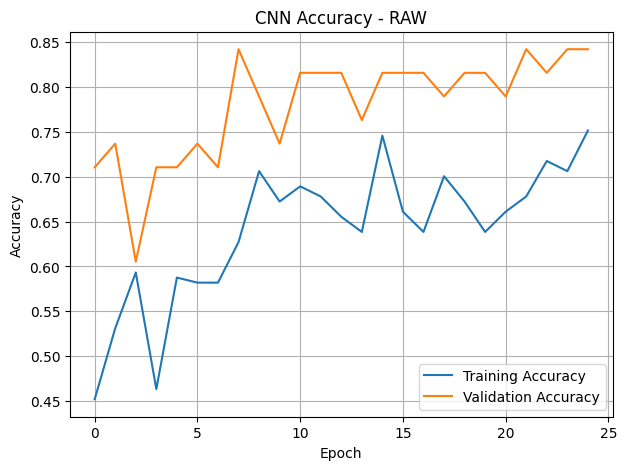

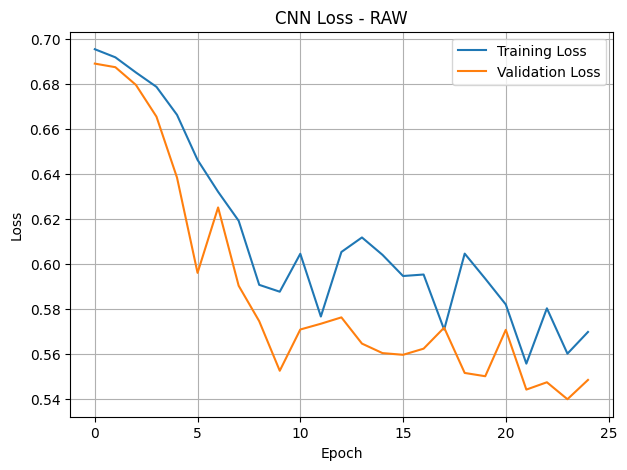

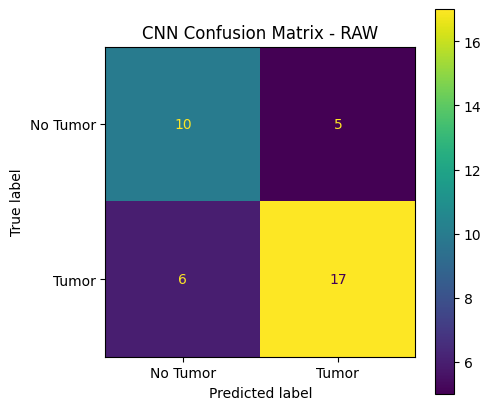

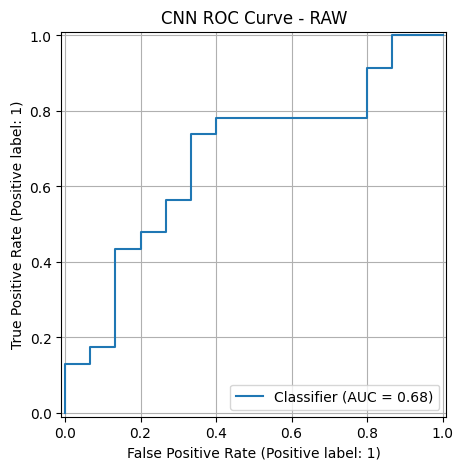

Training CNN on GHE images
Class weights: {np.int64(0): np.float64(1.2826086956521738), np.int64(1): np.float64(0.8194444444444444)}
Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 218ms/step - accuracy: 0.4689 - auc: 0.4721 - loss: 0.6960 - precision: 0.6591 - recall: 0.2685 - val_accuracy: 0.6316 - val_auc: 0.5372 - val_loss: 0.6864 - val_precision: 0.6316 - val_recall: 1.0000
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.5198 - auc: 0.5360 - loss: 0.6915 - precision: 0.6322 - recall: 0.5093 - val_accuracy: 0.3684 - val_auc: 0.5000 - val_loss: 0.6987 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.4972 - auc: 0.5225 - loss: 0.6935 - precision: 0.6610 - recall: 0.3611 - val_accuracy: 0.3684 - val_auc: 0.4256 - val_loss: 0.7037 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.3898 - auc: 0.4362 - loss: 0.7039 - precision: 0.5000 - rec

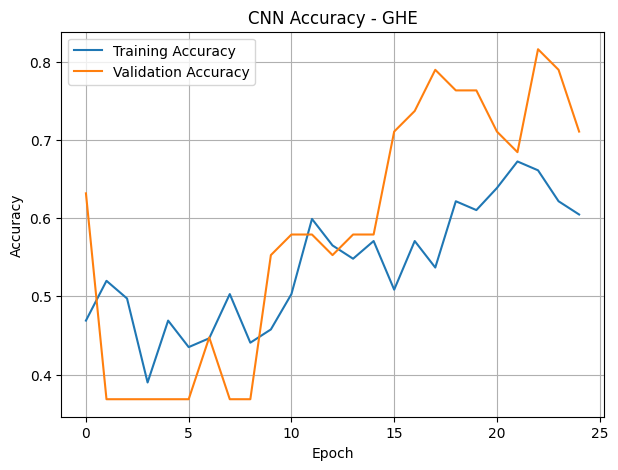

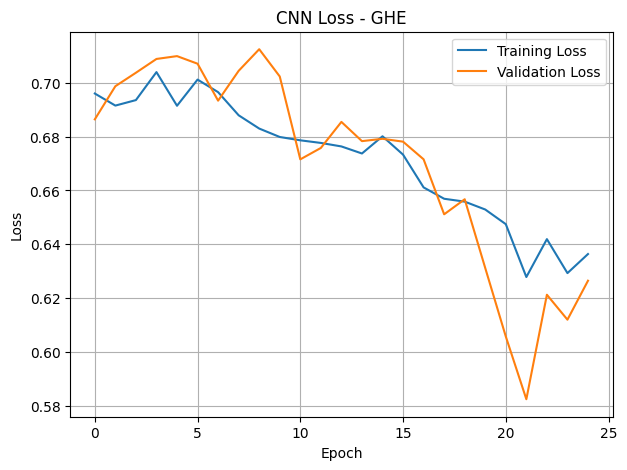

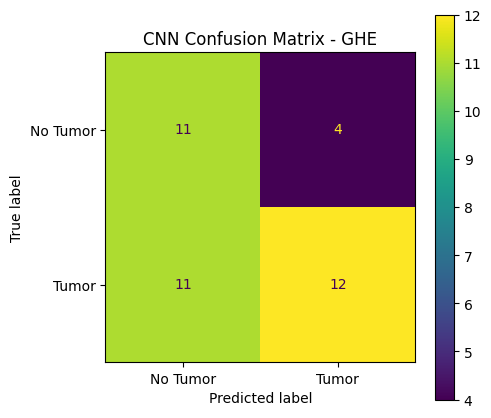

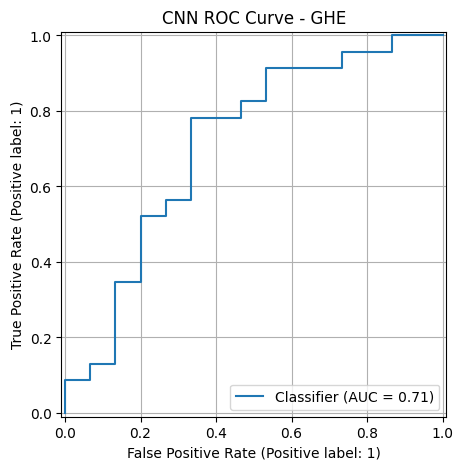

Training CNN on CLAHE images
Class weights: {np.int64(0): np.float64(1.2826086956521738), np.int64(1): np.float64(0.8194444444444444)}
Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 210ms/step - accuracy: 0.5819 - auc: 0.5205 - loss: 0.6944 - precision: 0.6197 - recall: 0.8148 - val_accuracy: 0.6316 - val_auc: 0.7827 - val_loss: 0.6692 - val_precision: 0.6316 - val_recall: 1.0000
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.5141 - auc: 0.4831 - loss: 0.6960 - precision: 0.5948 - recall: 0.6389 - val_accuracy: 0.6842 - val_auc: 0.6577 - val_loss: 0.6907 - val_precision: 0.8750 - val_recall: 0.5833
Epoch 3/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.5650 - auc: 0.6503 - loss: 0.6859 - precision: 0.7627 - recall: 0.4167 - val_accuracy: 0.3684 - val_auc: 0.7768 - val_loss: 0.6938 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.5254 - auc: 0.6569 - loss: 0.6815 - precision: 0.8333 - recall: 0

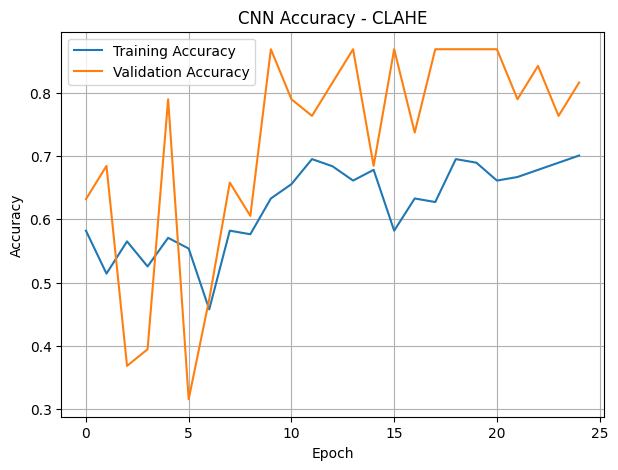

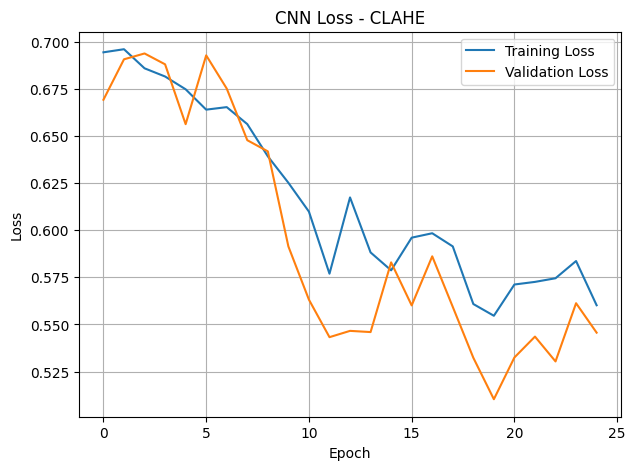

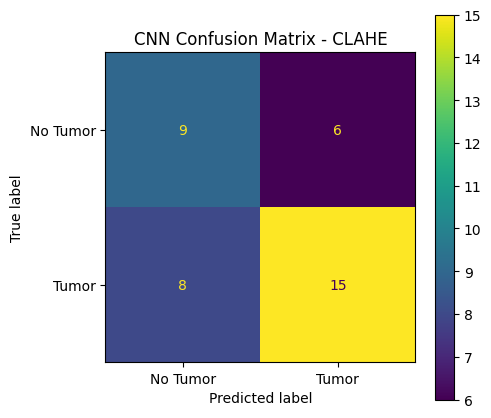

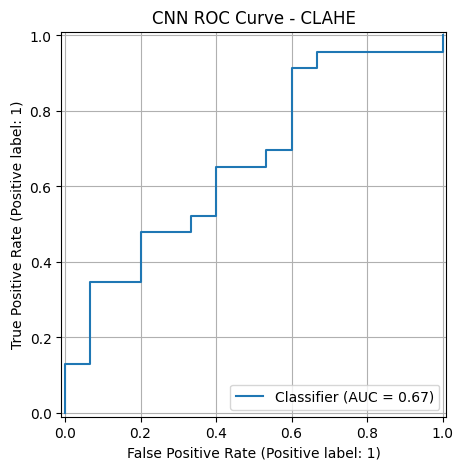

In [13]:
cnn_results = []

for method in methods:
    result = train_and_evaluate_cnn(method)
    cnn_results.append(result)

In [14]:
cnn_results_df = pd.DataFrame(cnn_results)

cnn_results_df

,model,preprocessing,accuracy,precision,recall,f1_score,roc_auc
0,CNN,raw,0.710526,0.772727,0.739130,0.755556,0.675362
1,CNN,ghe,0.605263,0.750000,0.521739,0.615385,0.713043
2,CNN,clahe,0.631579,0.714286,0.652174,0.681818,0.666667


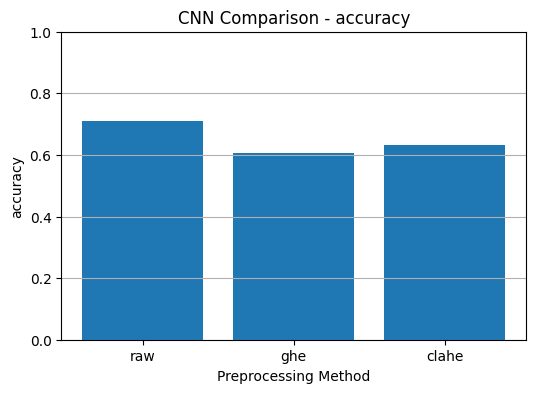

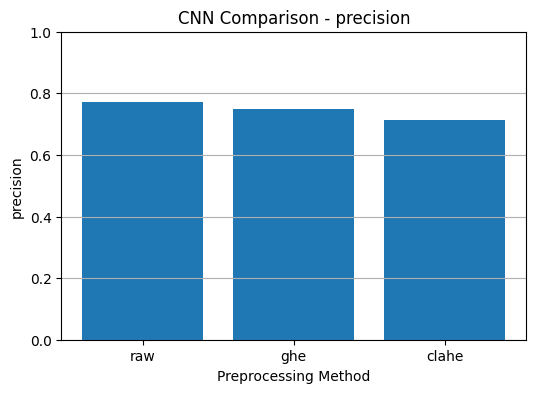

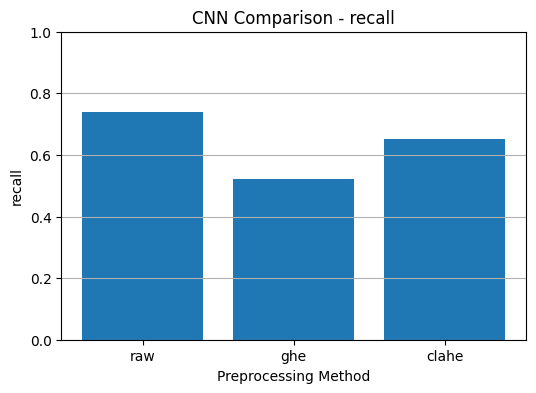

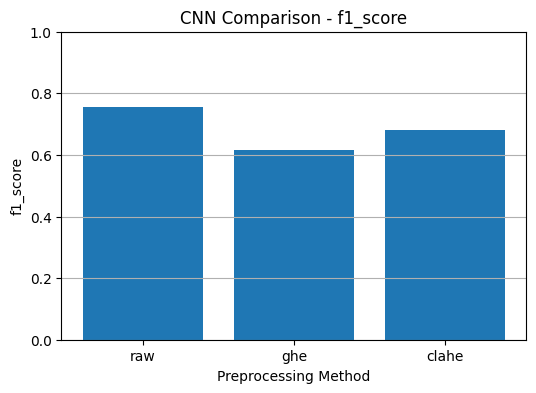

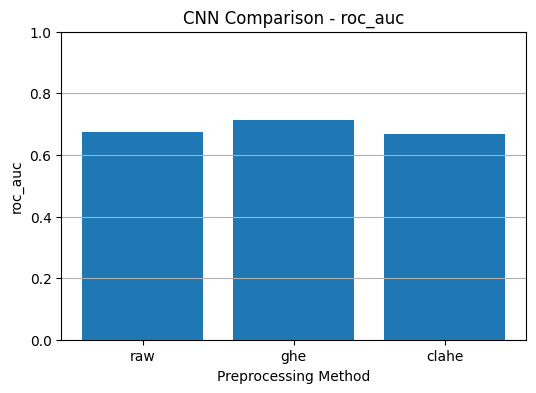

In [15]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    plt.bar(cnn_results_df["preprocessing"], cnn_results_df[metric])
    plt.title(f"CNN Comparison - {metric}")
    plt.xlabel("Preprocessing Method")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.grid(axis="y")
    plt.savefig(FIGURES_DIR / f"cnn_comparison_{metric}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [16]:
best_method = cnn_results_df.sort_values(by="f1_score", ascending=False).iloc[0]

print("Best CNN preprocessing method based on F1-score:")
print(best_method)

Best CNN preprocessing method based on F1-score:
model                 CNN
preprocessing         raw
accuracy         0.710526
precision        0.772727
recall            0.73913
f1_score         0.755556
roc_auc          0.675362
Name: 0, dtype: object


In [17]:
cnn_results_df.to_csv(RESULTS_DIR / "cnn_results.csv", index=False)